In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Bidirectional,
    LSTM, Dense, Dropout, LayerNormalization)
from tensorflow.keras.callbacks import (EarlyStopping,
    ReduceLROnPlateau)
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error,
    mean_squared_error)
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
df = pd.read_csv('../data/features.csv')
df = df[df['station_code']==153].copy()
df = df.sort_values('timestamp')
print("Rows:", len(df))

FEATURES = [
    'hour','day_of_week','month',
    'is_weekend','is_peak_hour',
    'hour_sin','hour_cos',
    'is_festival','festival_mult','is_cricket',
    'lag_1','lag_2','lag_4','lag_24',
    'roll_mean_4','roll_mean_24',
]

X = df[FEATURES].values
y = df['people_in'].values

Rows: 11038


In [3]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_sc = scaler_X.fit_transform(X)
y_sc = scaler_y.fit_transform(
    y.reshape(-1,1)).flatten()

SEQ_LEN = 8

def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_sc, y_sc, SEQ_LEN)
print("Sequence shape:", X_seq.shape)

Sequence shape: (11030, 8, 16)


In [4]:
split     = int(len(X_seq) * 0.80)
X_train   = X_seq[:split]
X_test    = X_seq[split:]
y_train   = y_seq[:split]
y_test    = y_seq[split:]

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (8824, 8, 16)
Test:  (2206, 8, 16)


In [5]:
n_features = X_train.shape[2]

model = Sequential([
    Bidirectional(
        LSTM(64, return_sequences=True),
        input_shape=(SEQ_LEN, n_features)),
    LayerNormalization(),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='huber',
    metrics=['mae'])

model.summary()

C:\Users\Aditya Bavkar\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\bidirectional.py:110: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 8, 128)         │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 8, 128)         │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,057 (332.25 KB)

 Trainable params: 85,057 (332.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
callbacks = [
    EarlyStopping(patience=8,
                  restore_best_weights=True,
                  monitor='val_mae'),
    ReduceLROnPlateau(patience=4,
                      factor=0.5,
                      min_lr=1e-5)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0065 - mae: 0.0793 - val_loss: 0.0019 - val_mae: 0.0494 - learning_rate: 0.0010
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0023 - mae: 0.0497 - val_loss: 0.0018 - val_mae: 0.0470 - learning_rate: 0.0010
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - mae: 0.0418 - val_loss: 0.0016 - val_mae: 0.0414 - learning_rate: 0.0010
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - mae: 0.0358 - val_loss: 7.3560e-04 - val_mae: 0.0271 - learning_rate: 0.0010
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010 - mae: 0.0323 - val_loss: 6.2181e-04 - val_mae: 0.0262 - learning_rate: 0.0010
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.4029e-04 - mae: 0.0301 - val_loss: 6.4160e-04 - val_mae: 0.0250 - learning_rate: 0.0010
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.5866e-04 - mae: 0.0281 - val_loss: 8.7805e-04 - val_mae: 0.0311 - lear

In [7]:
preds_sc = model.predict(X_test).flatten()
preds    = scaler_y.inverse_transform(
    preds_sc.reshape(-1,1)).flatten()
actual   = scaler_y.inverse_transform(
    y_test.reshape(-1,1)).flatten()

mae  = mean_absolute_error(actual, preds)
rmse = np.sqrt(mean_squared_error(actual, preds))
mape = np.mean(np.abs(
    (actual-preds)/np.clip(actual,1,None)))*100

print("="*40)
print(f"  MAE  : {mae:.1f} passengers")
print(f"  RMSE : {rmse:.1f}")
print(f"  MAPE : {mape:.2f}%")
print("="*40)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
  MAE  : 145.3 passengers
  RMSE : 212.0
  MAPE : 22.36%


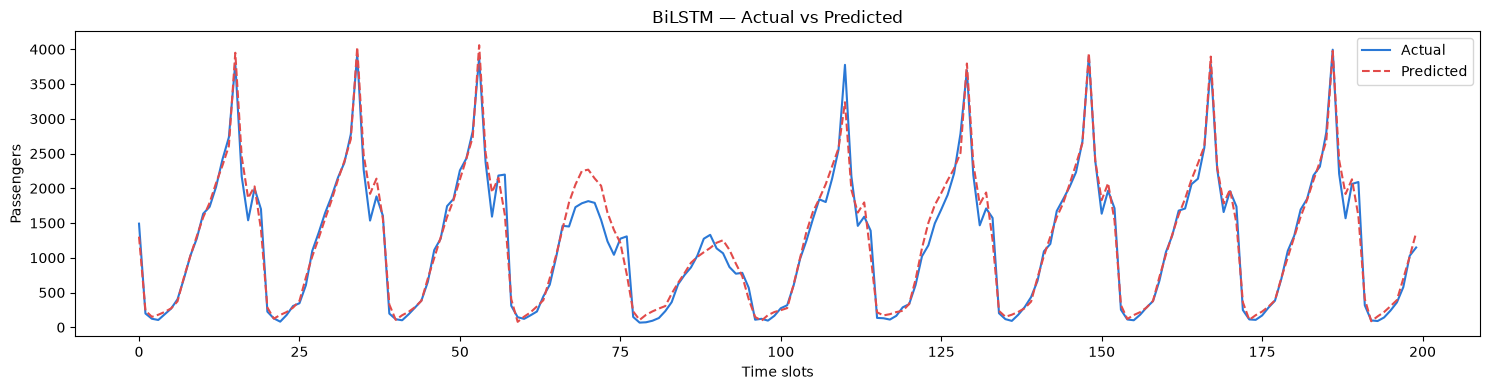

In [8]:
plt.figure(figsize=(15, 4))
plt.plot(actual[:200],
         label='Actual',    color='#2a78d6')
plt.plot(preds[:200],
         label='Predicted', color='#e24b4a',
         linestyle='--')
plt.title('BiLSTM — Actual vs Predicted')
plt.xlabel('Time slots')
plt.ylabel('Passengers')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/lstm_result.png')
plt.show()

In [9]:
model.save('../models/lstm_model.keras')
print("LSTM model saved")

LSTM model saved
